In [13]:
import pandas as pd
import seaborn as sns
from sklearn.preprocessing import StandardScaler,MinMaxScaler



In [14]:
df = sns.load_dataset('titanic')
df.head()

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True


In [15]:
df.shape

(891, 15)

In [16]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 15 columns):
 #   Column       Non-Null Count  Dtype   
---  ------       --------------  -----   
 0   survived     891 non-null    int64   
 1   pclass       891 non-null    int64   
 2   sex          891 non-null    object  
 3   age          714 non-null    float64 
 4   sibsp        891 non-null    int64   
 5   parch        891 non-null    int64   
 6   fare         891 non-null    float64 
 7   embarked     889 non-null    object  
 8   class        891 non-null    category
 9   who          891 non-null    object  
 10  adult_male   891 non-null    bool    
 11  deck         203 non-null    category
 12  embark_town  889 non-null    object  
 13  alive        891 non-null    object  
 14  alone        891 non-null    bool    
dtypes: bool(2), category(2), float64(2), int64(4), object(5)
memory usage: 80.7+ KB


In [17]:
df2 = df[['survived','pclass','age','parch']]
df2.head()

,survived,pclass,age,parch
0,0,3,22.0,0
1,1,1,38.0,0
2,1,3,26.0,0
3,1,1,35.0,0
4,0,3,35.0,0


In [18]:
df2.isnull().sum()

,0
survived,0
pclass,0
age,177
parch,0


In [19]:
df2['pclass'].mean()

np.float64(2.308641975308642)

In [20]:
df2['age'].mean()

np.float64(29.69911764705882)

In [21]:
df2.describe()

,survived,pclass,age,parch
count,891.000000,891.000000,714.000000,891.000000
mean,0.383838,2.308642,29.699118,0.381594
std,0.486592,0.836071,14.526497,0.806057
min,0.000000,1.000000,0.420000,0.000000
25%,0.000000,2.000000,20.125000,0.000000
50%,0.000000,3.000000,28.000000,0.000000
75%,1.000000,3.000000,38.000000,0.000000
max,1.000000,3.000000,80.000000,6.000000


In [22]:
df_fill = df2.fillna(df2.mean())


In [23]:
X = df_fill.drop('survived',axis=1)
y = df_fill['survived']

In [24]:
print('Shape of X = ',X.shape)
print('Shape of y = ',y.shape)

Shape of X =  (891, 3)
Shape of y =  (891,)


In [25]:
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2,random_state=42)

In [26]:
print('Shape of X_train = ',X_train.shape)
print('Shape of y_train = ',y_train.shape)
print('Shape of X_test = ',X_test.shape)
print('Shape of y_test = ',y_test.shape)

Shape of X_train =  (712, 3)
Shape of y_train =  (712,)
Shape of X_test =  (179, 3)
Shape of y_test =  (179,)


In [27]:
sc = StandardScaler()
sc.fit(X_train)


StandardScaler()

In [28]:
sc.mean_

array([ 2.33005618, 29.53822538,  0.37921348])

In [29]:
sc.scale_

array([ 0.82400502, 12.98541943,  0.79111317])

In [30]:
X_train.describe()

,pclass,age,parch
count,712.000000,712.000000,712.000000
mean,2.330056,29.538225,0.379213
std,0.824584,12.994548,0.791669
min,1.000000,0.420000,0.000000
25%,2.000000,22.000000,0.000000
50%,3.000000,29.699118,0.000000
75%,3.000000,35.000000,0.000000
max,3.000000,80.000000,6.000000


In [31]:
sc.transform(X_train)

array([[-1.61413602,  1.22920747, -0.47934164],
       [-0.40055118, -0.50350514, -0.47934164],
       [ 0.81303367,  0.18957991, -0.47934164],
       ...,
       [ 0.81303367,  0.88266495, -0.47934164],
       [-1.61413602, -1.19659018,  2.04874166],
       [-1.61413602, -0.65752403,  0.78470001]])

In [32]:
X_train_sc = sc.transform(X_train)


In [33]:
X_train_sc

array([[-1.61413602,  1.22920747, -0.47934164],
       [-0.40055118, -0.50350514, -0.47934164],
       [ 0.81303367,  0.18957991, -0.47934164],
       ...,
       [ 0.81303367,  0.88266495, -0.47934164],
       [-1.61413602, -1.19659018,  2.04874166],
       [-1.61413602, -0.65752403,  0.78470001]])

In [34]:
X_train_sc = pd.DataFrame(X_train_sc,columns=['pclass','age','parch'])
X_test_sc = sc.transform(X_test)
X_test_sc = pd.DataFrame(X_test_sc,columns=['pclass','age','parch'])

In [35]:
X_test_sc = pd.DataFrame(X_test_sc,columns=['pclass','age','parch'])

In [36]:
X_train

,pclass,age,parch
331,1,45.500000,0
733,2,23.000000,0
382,3,32.000000,0
704,3,26.000000,0
813,3,6.000000,2
...,...,...,...
106,3,21.000000,0
270,1,29.699118,0
860,3,41.000000,0
435,1,14.000000,2


In [37]:
X_train_sc.describe().round(2)

,pclass,age,parch
count,712.00,712.00,712.00
mean,0.00,0.00,0.00
std,1.00,1.00,1.00
min,-1.61,-2.24,-0.48
25%,-0.40,-0.58,-0.48
50%,0.81,0.01,-0.48
75%,0.81,0.42,-0.48
max,0.81,3.89,7.10


In [38]:
mmc = MinMaxScaler()
mmc.fit(X_train)

MinMaxScaler()

In [39]:
X_train_mmc = mmc.transform(X_train)


In [40]:
X_train_mmc

array([[0.        , 0.56647399, 0.        ],
       [0.5       , 0.28373963, 0.        ],
       [1.        , 0.39683338, 0.        ],
       ...,
       [1.        , 0.50992712, 0.        ],
       [0.        , 0.17064589, 0.33333333],
       [0.        , 0.25860769, 0.16666667]])

In [41]:
X_test_mmc = mmc.transform(X_test)

In [42]:
X_test_mmc

array([[1.        , 0.36792055, 0.16666667],
       [0.5       , 0.3842674 , 0.        ],
       [1.        , 0.24604172, 0.        ],
       [0.5       , 0.07011812, 0.16666667],
       [1.        , 0.17064589, 0.        ],
       [0.        , 0.32143755, 0.        ],
       [1.        , 0.36792055, 0.        ],
       [1.        , 0.19577783, 0.        ],
       [1.        , 0.19577783, 0.        ],
       [0.        , 0.23347575, 0.33333333],
       [0.        , 0.45966323, 0.        ],
       [1.        , 0.54762503, 0.        ],
       [1.        , 0.36792055, 0.16666667],
       [1.        , 0.37170143, 0.        ],
       [0.5       , 0.44709726, 0.        ],
       [0.        , 0.19577783, 0.16666667],
       [0.        , 0.52249309, 0.        ],
       [1.        , 0.36792055, 0.        ],
       [0.5       , 0.33400352, 0.        ],
       [0.        , 0.58532295, 0.        ],
       [1.        , 0.2963056 , 0.        ],
       [0.        , 0.42196532, 0.        ],
       [1.

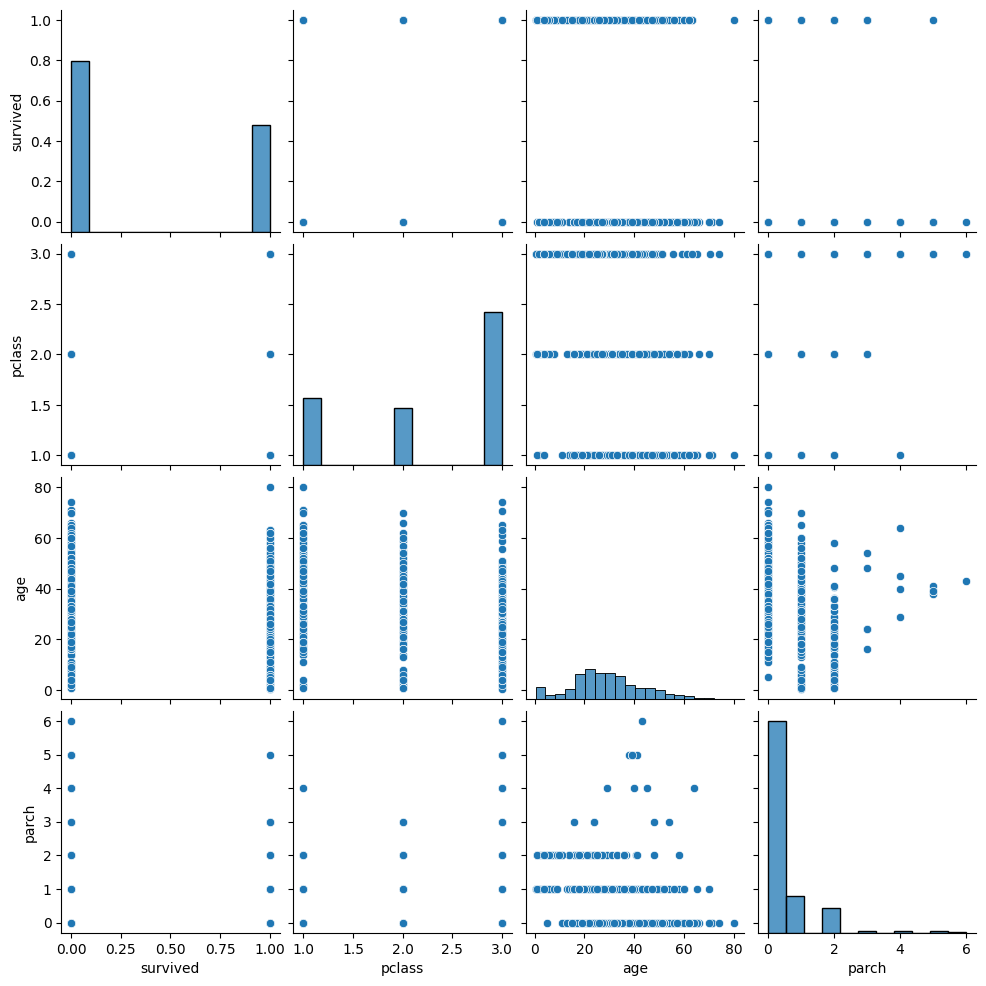

In [43]:
sns.pairplot(df2)

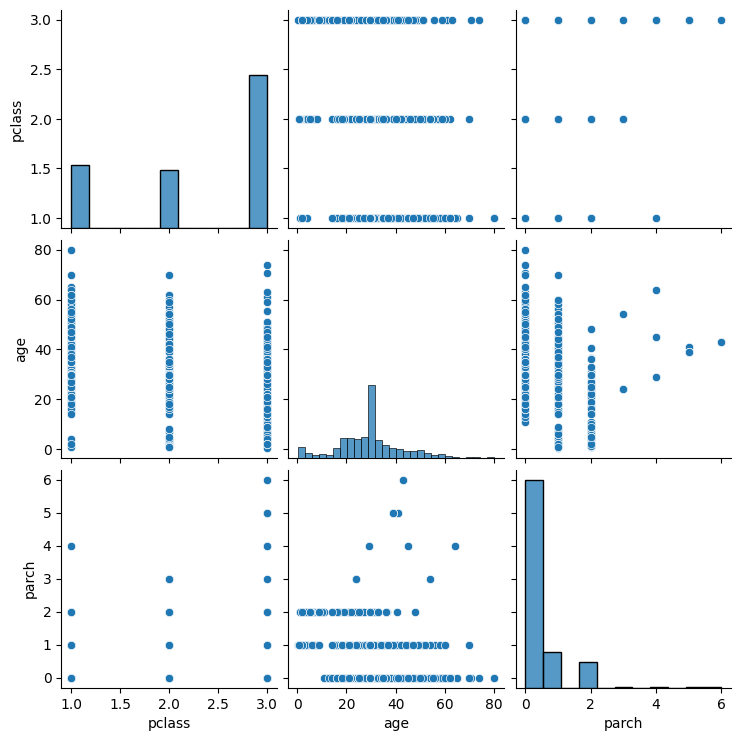

In [44]:
sns.pairplot(X_train)

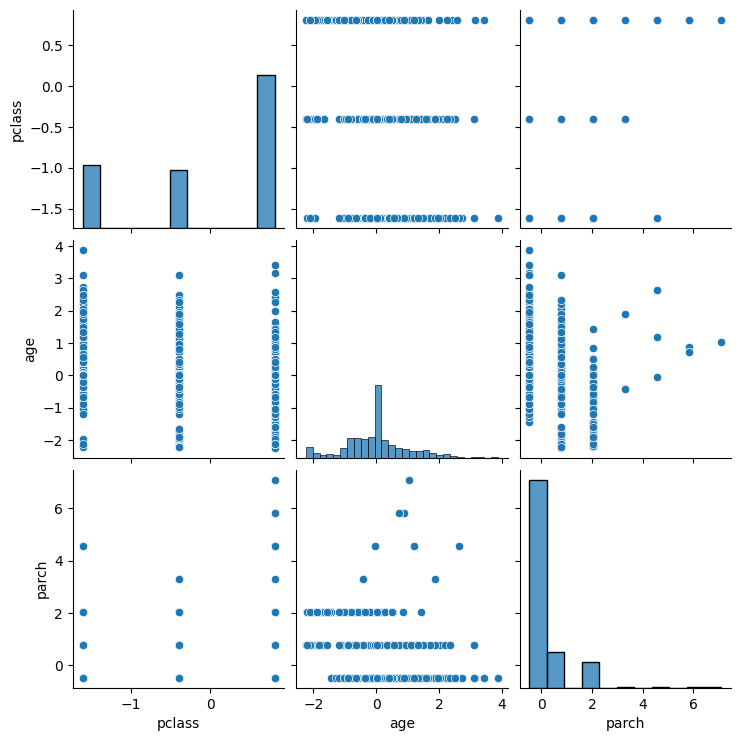

In [45]:
sns.pairplot(X_train_sc)

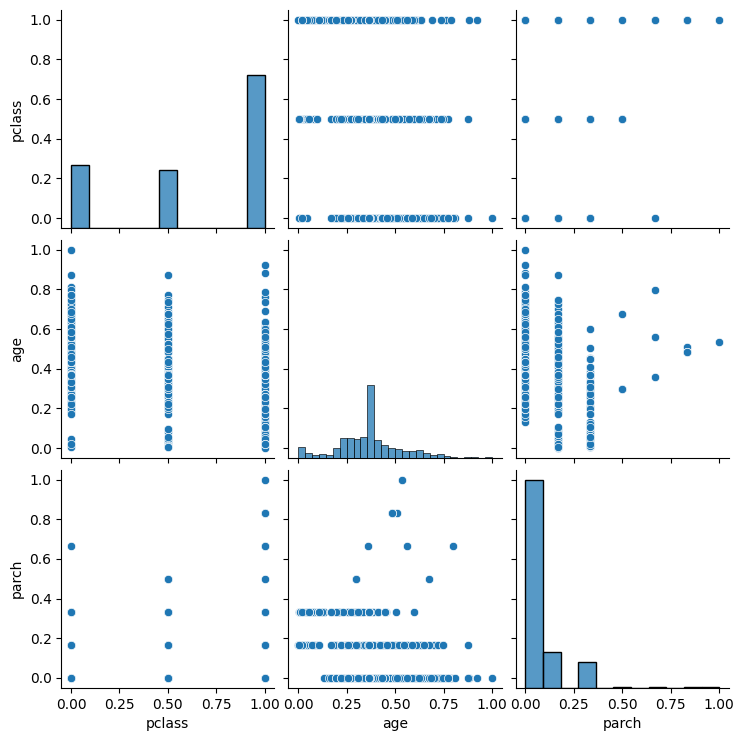

In [46]:
X_train_mmc = pd.DataFrame(X_train_mmc, columns=['pclass','age','parch'])
sns.pairplot(X_train_mmc)

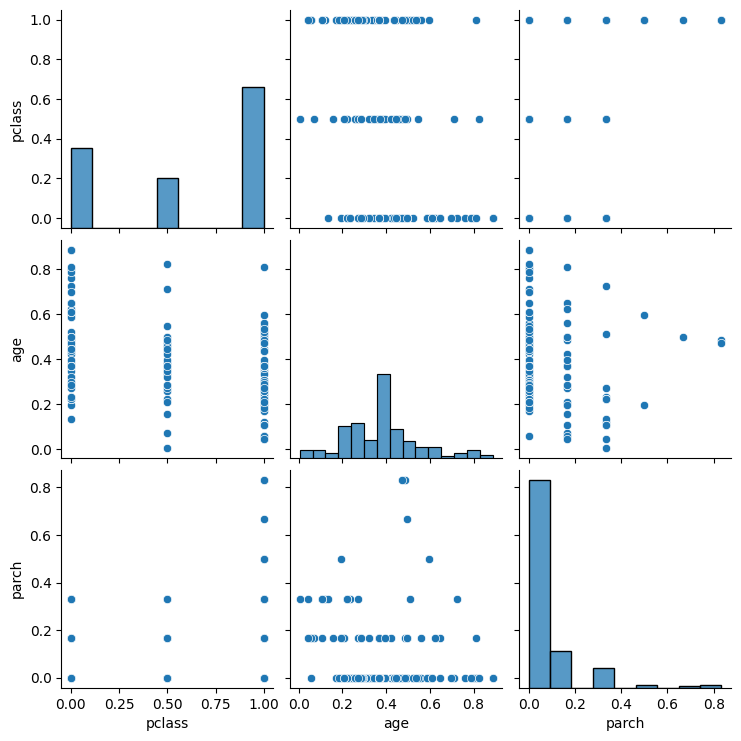

In [48]:
X_test_mmc = pd.DataFrame(X_test_mmc, columns=['pclass','age','parch'])
sns.pairplot(X_test_mmc)